In [1]:
# coincident_waveforms_fast_window_20_ticks_coinc_adc_4000_save_adc_4000.root
import ROOT
import numpy as np
import matplotlib.pyplot as plt


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
channels_dict = {
    "CH_M3_1": 2030, 
    "CH_M3_2": 2031, 
    "CH_M4_1": 2040, 
    "CH_M4_2": 2041, 
    "CH_M5_1": 2050, 
    "CH_M5_2": 2051, 
    "CH_M6_1": 2060, 
    "CH_M6_2": 2061,
    "CH_M7_1": 2070,
    "CH_M7_2": 2071,
    "CH_M8_1": 2080,
    "CH_M8_2": 2081
}

In [3]:
channels_forCoincidenceLeft = np.array(list(channels_dict.values(   )), dtype=int)[:4]
channels_forCoincidenceRight = np.array(list(channels_dict.values(   )), dtype=int)[4:8]
channels_toSaveWF = np.array(list(channels_dict.values(   )), dtype=int)[-4:]
channels_forCoincidence = np.array(list(channels_dict.values(   )), dtype=int)[0:8]
print(channels_forCoincidence, channels_forCoincidenceLeft, channels_forCoincidenceRight,channels_toSaveWF)

[2030 2031 2040 2041 2050 2051 2060 2061] [2030 2031 2040 2041] [2050 2051 2060 2061] [2070 2071 2080 2081]


In [4]:
channels_toSaveWF_dict = {k: v for i, (k, v) in enumerate(channels_dict.items()) if i >= len(channels_dict) - 4}
print(channels_toSaveWF_dict)

{'CH_M7_1': 2070, 'CH_M7_2': 2071, 'CH_M8_1': 2080, 'CH_M8_2': 2081}


In [7]:
f_inroot = ROOT.TFile.Open("deconvolved_coincident_waveforms_fast_window_20_ticks_coinc_adc_4000_save_adc_4000.root")
tree = f_inroot.Get("DeconvolvedWaveforms")

tree.SetBranchStatus("*", 1)
df = ROOT.RDataFrame(tree)

valid_channels = np.array(sorted(channels_toSaveWF_dict.values()), dtype=np.int64)
channel_filter = " || ".join(f"saved_channel == {int(ch)}" for ch in valid_channels)

print(channel_filter)
arr = (
    df.Filter(channel_filter)
      .AsNumpy(["event", "saved_channel", "saved_waveform_index", "adc_deconvolved_filtered"])
)

events = arr["event"].astype(np.int64, copy=False)
wf = arr["adc_deconvolved_filtered"]
wf_index = arr["saved_waveform_index"].astype(np.int64, copy=False)
channel_arr = arr["saved_channel"].astype(np.int64, copy=False)

print(f"Total waveforms collected: {len(events)}")


saved_channel == 2070 || saved_channel == 2071 || saved_channel == 2080 || saved_channel == 2081
Total waveforms collected: 67544


Unique waveforms: 67544 / 67544


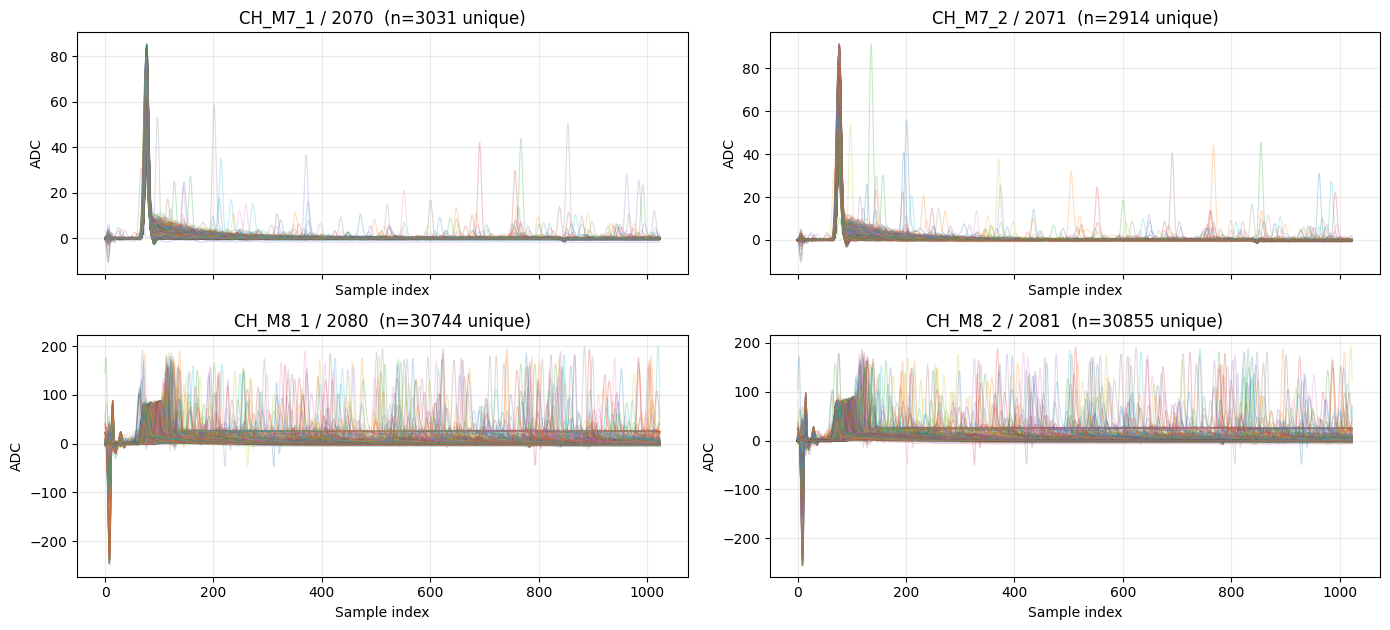

In [8]:
# Plot all unique saved waveforms per channel

channel_name = {v: k for k, v in channels_toSaveWF_dict.items()}

# Unique waveform identity in the coincidence file
keys = np.rec.fromarrays(
    [events, channel_arr, wf_index],
    names=["event", "channel", "wf_index"],
)

_, unique_pos = np.unique(keys, return_index=True)
unique_pos = np.sort(unique_pos)

print(f"Unique waveforms: {len(unique_pos)} / {len(events)}")

unique_counts = {
    ch: int(np.sum(channel_arr[unique_pos] == ch))
    for ch in valid_channels
}

ncols = 2
nrows = int(np.ceil(len(valid_channels) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 3.2 * nrows),
    sharex=True,
)
axes = axes.flatten()

for ax, ch in zip(axes, valid_channels):
    idx = unique_pos[channel_arr[unique_pos] == ch]

    for i in idx:
        y = np.asarray(wf[i], dtype=float)
        x = np.arange(len(y))
        ax.plot(x, y, lw=0.8, alpha=0.25)

    label = channel_name.get(int(ch), f"CH {ch}")
    ax.set_title(f"{label} / {ch}  (n={len(idx)} unique)")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("ADC")
    ax.grid(alpha=0.25)

for ax in axes[len(valid_channels):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from hashlib import md5

def waveform_hash(waveform):
    arr = np.asarray(waveform, dtype=np.float64)
    return md5(arr.tobytes()).hexdigest()

all_hashes = [waveform_hash(wf[i]) for i in unique_pos]
n_plotted = len(all_hashes)
n_unique = len(set(all_hashes))

print(f"Plotted waveforms: {n_plotted}")
print(f"Unique waveform arrays: {n_unique}")
if n_plotted == n_unique:
    print("All plotted waveforms are unique.")
else:
    print(f"{n_plotted - n_unique} duplicate waveforms found across all channels.")

for ch in valid_channels:
    idx = unique_pos[channel_arr[unique_pos] == ch]
    ch_hashes = [waveform_hash(wf[i]) for i in idx]
    n_ch = len(ch_hashes)
    n_ch_unique = len(set(ch_hashes))
    print(
        f"{channel_name.get(int(ch), ch)} ({ch}): "
        f"{n_ch} plotted, {n_ch_unique} unique, {n_ch - n_ch_unique} duplicates"
    )

Plotted waveforms: 67544
Unique waveform arrays: 67544
All plotted waveforms are unique.
CH_M7_1 (2070): 3031 plotted, 3031 unique, 0 duplicates
CH_M7_2 (2071): 2914 plotted, 2914 unique, 0 duplicates
CH_M8_1 (2080): 30744 plotted, 30744 unique, 0 duplicates
CH_M8_2 (2081): 30855 plotted, 30855 unique, 0 duplicates
